In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# CELL 1 — LOAD LIQUID OPTIONS
# ==========================================
folder = r"C:\Users\ASUS\Desktop\volPredict"
file_path = os.path.join(folder, "options_liquid.csv")

print("=== LOADING LIQUID OPTIONS DATA ===")
df = pd.read_csv(file_path)

# Parse dates
df["Date"] = pd.to_datetime(df["Date"])
df["Expiry"] = pd.to_datetime(df["Expiry"])

print(f"✓ Loaded {len(df):,} liquid option records ready for IV calculation.")

=== LOADING LIQUID OPTIONS DATA ===
✓ Loaded 386,942 liquid option records ready for IV calculation.


In [2]:
# ==========================================
# CELL 1.5 — RECOVER MARKET-IMPLIED FORWARD PRICE
# ==========================================
# WHY THIS CELL EXISTS:
# The old code fed raw spot ("Underlying Value") into Black-Scholes with a
# guessed flat rate (r=5%). Index options are actually priced off the FUTURES
# price, which differs from spot by the cost-of-carry (interest rate minus
# dividends). Getting that carry wrong makes calls and puts mis-price in
# OPPOSITE directions -> looks like a vertical shift between call-IV and
# put-IV rather than a real smile.
#
# FIX: put-call parity says, for the same strike K and expiry:
#     Call_price - Put_price = (Forward - K) * discount_factor
# This is a straight line if you plot (Call - Put) against K.
# - Where that line crosses zero is exactly K = Forward.
# - The slope of that line is -discount_factor (so we recover the discount
#   factor too, without ever assuming an interest rate ourselves).
# We fit this line separately for every (Date, Expiry) pair, using only
# strikes where BOTH a call and a put exist (so they're directly comparable).

print("=== EXTRACTING FORWARD PRICE VIA PUT-CALL PARITY ===")

def extract_forward_for_group(group):
    """
    group: all CE and PE rows for ONE (Date, Expiry) pair.
    Returns fitted Forward price and discount factor, or NaN if not enough data.
    """
    calls = group[group["Type"] == "CE"][["Strike Price", "Close"]].rename(columns={"Close": "Call_Close"})
    puts = group[group["Type"] == "PE"][["Strike Price", "Close"]].rename(columns={"Close": "Put_Close"})

    merged = pd.merge(calls, puts, on="Strike Price", how="inner")

    # Need at least 3 matched strikes to fit a reliable line
    if len(merged) < 3:
        return pd.Series({"Forward": np.nan, "DiscountFactor": np.nan, "N_Strikes_Used": len(merged)})

    K = merged["Strike Price"].values
    C_minus_P = (merged["Call_Close"] - merged["Put_Close"]).values

    # Fit: (C - P) = slope * K + intercept
    # Parity says: (C - P) = -discount_factor * K + discount_factor * Forward
    slope, intercept = np.polyfit(K, C_minus_P, 1)

    discount_factor = -slope
    if discount_factor <= 0:
        # Bad fit (illiquid/noisy strikes) - discard
        return pd.Series({"Forward": np.nan, "DiscountFactor": np.nan, "N_Strikes_Used": len(merged)})

    forward = intercept / discount_factor

    return pd.Series({"Forward": forward, "DiscountFactor": discount_factor, "N_Strikes_Used": len(merged)})


forward_table = (
    df.groupby(["Date", "Expiry"], group_keys=True)
    .apply(extract_forward_for_group)
    .reset_index()
)

n_total = len(forward_table)
n_valid = forward_table["Forward"].notna().sum()
print(f"✓ Fitted forward price for {n_valid:,} / {n_total:,} (Date, Expiry) groups.")
print(f"  Dropped {n_total - n_valid:,} groups with <3 matched strikes or a bad parity fit.")

# Merge the fitted forward + discount factor back onto every option row
df = df.merge(forward_table[["Date", "Expiry", "Forward", "DiscountFactor"]], on=["Date", "Expiry"], how="left")

# Sanity check: forward should be close to (but not identical to) Underlying Value
df["Forward_vs_Spot_pct"] = (df["Forward"] / df["Underlying Value"] - 1) * 100
print()
print("--- Sanity check: Forward vs Spot (% difference) ---")
print(df["Forward_vs_Spot_pct"].describe())

# Drop rows where we couldn't fit a forward (illiquid expiry-dates)
before = len(df)
df = df.dropna(subset=["Forward", "DiscountFactor"]).copy()
print(f"\n✓ Dropped {before - len(df):,} rows lacking a valid forward. {len(df):,} rows remain.")

=== EXTRACTING FORWARD PRICE VIA PUT-CALL PARITY ===
✓ Fitted forward price for 5,284 / 6,724 (Date, Expiry) groups.
  Dropped 1,440 groups with <3 matched strikes or a bad parity fit.

--- Sanity check: Forward vs Spot (% difference) ---
count    378932.000000
mean          0.553625
std           0.829806
min          -2.370888
25%           0.141058
50%           0.335876
75%           0.688488
max          11.442045
Name: Forward_vs_Spot_pct, dtype: float64

✓ Dropped 8,010 rows lacking a valid forward. 378,932 rows remain.


In [3]:
# ==========================================
# CELL 2 — VECTORIZED NEWTON-RAPHSON IV SOLVER
# ==========================================
print("=== DEFINING BSM IV ENGINE ===")

def vectorized_implied_volatility(S, K, T, market_price, flag, r=0.05, q=0.0, tol=1e-4, max_iter=100):
    """
    Computes Black-Scholes Implied Volatility for arrays using Newton-Raphson.
    S: Underlying Spot, K: Strike, T: Time to maturity (years)
    flag: 'CE' or 'PE', r: Risk-free rate (default 5%), q: Div yield
    """
    # Initialize IV at 30% (0.3)
    sigma = np.full_like(S, 0.3, dtype=float)
    
    # Pre-compute discounting factors
    exp_qT = np.exp(-q * T)
    exp_rT = np.exp(-r * T)
    
    # Create mask for Calls vs Puts (True for Calls, False for Puts)
    is_call = (flag == 'CE')

    for i in range(max_iter):
        sigma_sqrt_T = sigma * np.sqrt(T)
        
        # Prevent division by zero
        sigma_sqrt_T = np.where(sigma_sqrt_T == 0, 1e-9, sigma_sqrt_T)

        d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / sigma_sqrt_T
        d2 = d1 - sigma_sqrt_T

        # Calculate model prices
        price_c = S * exp_qT * norm.cdf(d1) - K * exp_rT * norm.cdf(d2)
        price_p = K * exp_rT * norm.cdf(-d2) - S * exp_qT * norm.cdf(-d1)
        
        model_price = np.where(is_call, price_c, price_p)

        # Calculate Vega (same for call and put)
        vega = S * exp_qT * norm.pdf(d1) * np.sqrt(T)
        # Prevent division by near-zero vega
        vega = np.where(vega < 1e-6, 1e-6, vega)

        diff = model_price - market_price
        
        # Update step (Newton-Raphson)
        step = diff / vega
        sigma = sigma - step
        
        # Ensure volatility doesn't go negative or unreasonably high
        sigma = np.clip(sigma, 1e-4, 5.0)
        
        # Check convergence
        if np.max(np.abs(diff)) < tol:
            break

    return sigma

print("✓ BSM Engine defined successfully.")

=== DEFINING BSM IV ENGINE ===
✓ BSM Engine defined successfully.


In [4]:
# ==========================================
# CELL 3 — SOLVE IV USING FITTED FORWARD (not raw spot / guessed rate)
# ==========================================
# Key change from before: since we already have the market discount factor
# from the parity fit (exp(-r*T) implied by the market itself), we pass the
# FORWARD as S and set r=0 in the solver. That's mathematically equivalent to
# using spot with the correct index-specific carry rate, but we never have to
# guess the rate — the market already told us via put-call parity.

print("=== SOLVING IMPLIED VOLATILITY (FORWARD-BASED) ===")

S = df["Forward"].values
K = df["Strike Price"].values
T = df["DTE"].values / 365.0
market_price = df["Close"].values
flag = df["Type"].values

df["IV"] = vectorized_implied_volatility(S, K, T, market_price, flag, r=0.0, q=0.0)

print(f"✓ Solved IV for {len(df):,} option records.")
print()
print("--- IV distribution ---")
print(df["IV"].describe())

=== SOLVING IMPLIED VOLATILITY (FORWARD-BASED) ===
✓ Solved IV for 378,932 option records.

--- IV distribution ---
count    378932.000000
mean          0.166486
std           0.084393
min           0.000100
25%           0.124331
50%           0.149570
75%           0.192377
max           1.769632
Name: IV, dtype: float64


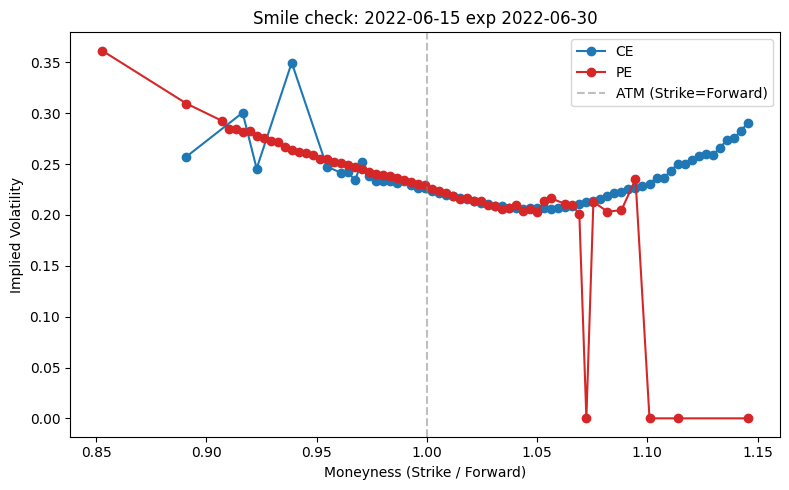

✓ If the fix worked, CE and PE points should form ONE curve, not two shifted lines.


In [5]:
# ==========================================
# CELL 4 — CHECK THE SMILE SHIFT IS FIXED
# ==========================================
# Pick one liquid expiry-date to sanity check visually. Before the fix, CALL
# IV and PUT IV would sit on two roughly-parallel lines, offset vertically.
# After the fix, they should trace out ONE continuous smile/skew curve as a
# function of moneyness (K/Forward), meeting near the at-the-money point.

import matplotlib.pyplot as plt

df["Moneyness_Fwd"] = df["Strike Price"] / df["Forward"]

sample_date = df["Date"].iloc[len(df)//2]
sample = df[df["Date"] == sample_date]
sample_expiry = sample["Expiry"].value_counts().idxmax()
sample = sample[sample["Expiry"] == sample_expiry].sort_values("Strike Price")

fig, ax = plt.subplots(figsize=(8, 5))
for opt_type, color in [("CE", "tab:blue"), ("PE", "tab:red")]:
    sub = sample[sample["Type"] == opt_type]
    ax.plot(sub["Moneyness_Fwd"], sub["IV"], "o-", label=opt_type, color=color)

ax.axvline(1.0, linestyle="--", color="gray", alpha=0.5, label="ATM (Strike=Forward)")
ax.set_xlabel("Moneyness (Strike / Forward)")
ax.set_ylabel("Implied Volatility")
ax.set_title(f"Smile check: {sample_date.date()} exp {sample_expiry.date()}")
ax.legend()
plt.tight_layout()
plt.savefig("smile_check.png", dpi=100)
plt.show()
print("✓ If the fix worked, CE and PE points should form ONE curve, not two shifted lines.")